# STEP 1. Installing Libraries & Downloading Data

In [1]:
!pip install yfinance --quiet
import yfinance as yf
import pandas as pd
df = yf.download("AAPL", start='2020-01-01', end='2024-12-31')
df.head()

/tmp/ipykernel_42630/2720540444.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start='2020-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


# STEP 2.Flattening columns & clean up

In [2]:
df.columns = df.columns.get_level_values(0)
df = df.reset_index()
df.columns.name = None
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
1,2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2,2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
3,2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


# STEP 3. Exploring the data

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1257 non-null   datetime64[ns]
 1   Close   1257 non-null   float64       
 2   High    1257 non-null   float64       
 3   Low     1257 non-null   float64       
 4   Open    1257 non-null   float64       
 5   Volume  1257 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.1 KB


,Date,Close,High,Low,Open,Volume
count,1257,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,2022-06-30 22:13:27.637231616,151.300258,152.820988,149.602776,151.144223,9.061168e+07
min,2020-01-02 00:00:00,54.163700,55.160698,51.324796,55.059309,2.323470e+07
25%,2021-04-01 00:00:00,126.249870,127.334355,124.234801,125.724390,5.546960e+07
50%,2022-06-30 00:00:00,149.942230,151.690680,147.948369,149.768118,7.629970e+07
75%,2023-09-29 00:00:00,175.746506,177.445018,174.316208,175.593375,1.077601e+08
max,2024-12-30 00:00:00,257.375549,258.448710,255.994390,256.550832,4.265100e+08
std,NaN,41.778189,41.916450,41.553581,41.717783,5.324605e+07


# STEP 4. Feature Engineering(creating targets)

In [4]:
#Creating target which is next days' closing price
df['Target'] = df['Close'].shift(-1)
#Droping last row as it has no text day for prediction
df.dropna()
#Overview
df[[ 'Date', 'Close', 'Target']].head()


,Date,Close,Target
0,2020-01-02,72.333862,71.630653
1,2020-01-03,71.630653,72.201408
2,2020-01-06,72.201408,71.861855
3,2020-01-07,71.861855,73.017830
4,2020-01-08,73.017830,74.568787


In [13]:
df = df.dropna(subset=['Target'])
print(df.isna().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Target    0
dtype: int64


# STEP 5. Selecting Features & Target

In [15]:
x = df[['Open', 'High', 'Low', 'Close', 'Volume']]
y = df['Target']
x.head()

,Open,High,Low,Close,Volume
0,71.344039,72.394070,71.091169,72.333862,135480400
1,71.563221,72.389273,71.406681,71.630653,146322800
2,70.754014,72.239942,70.503546,72.201408,118387200
3,72.211056,72.466338,71.642697,71.861855,108872000
4,71.565614,73.318870,71.565614,73.017830,132079200


# STEP 6. Splitting into Training & Test Sets

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size = 0.2, random_state = 42, shuffle = False )

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

x_train: (1004, 5)
x_test: (252, 5)


# STEP 8. Training the Model

In [17]:
from sklearn.linear_model import LinearRegression
Model = LinearRegression()
Model.fit(x_train, y_train)

LinearRegression()

# STEP 8. Making Predictions

In [18]:
pred_y = Model.predict(x_test)
pred_y[:10]

array([191.63093684, 190.31175881, 183.26083754, 182.5661775 ,
       179.99794658, 179.16244385, 183.2283811 , 182.78440051,
       184.13620207, 182.99524681])

# STEP 9. Evaluating performance

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred_y)
rmse = np.sqrt(mean_squared_error(y_test, pred_y))
r2 = r2_score(y_test, pred_y)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 2.169314807462857
RMSE: 2.9247293724249492
R² Score: 0.986711253218198


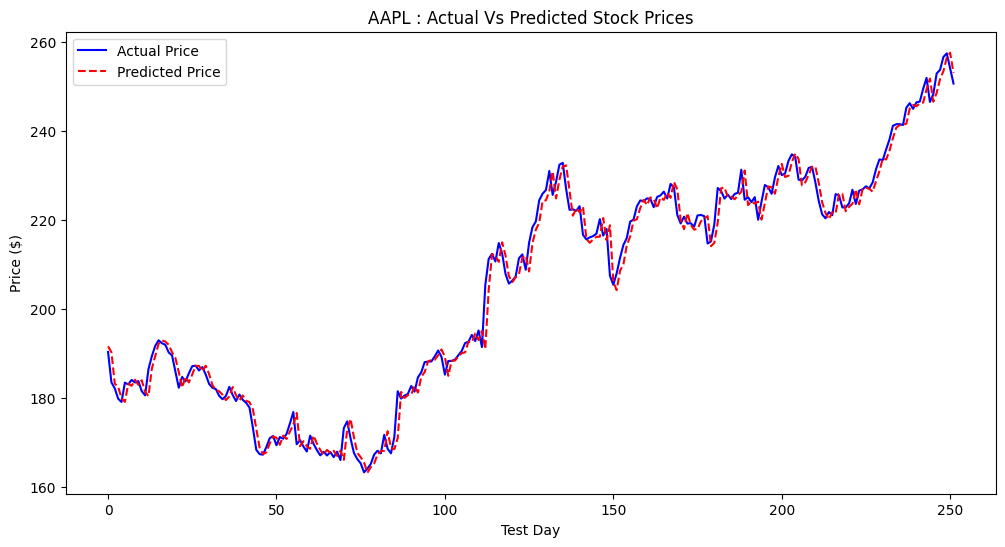

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label = "Actual Price", color = "blue")
plt.plot(pred_y, label="Predicted Price", color= "red", linestyle="--")
plt.title("AAPL : Actual Vs Predicted Stock Prices")
plt.xlabel("Test Day")
plt.ylabel("Price ($)")
plt.legend()
plt.show()